In [1]:
# =========================
# CELL 1: INSTALL & IMPORT
# =========================

!pip install -q pandas numpy requests openpyxl

import pandas as pd
import numpy as np
import requests
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded.')


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Libraries loaded.


In [3]:
# =========================
# CELL 2: LOAD WONDER DATA
# =========================

wonder_raw = pd.read_csv('Underlying Cause of Death, 2018-2024, Single Race (2).csv')

# Strip CDC footer notes (rows where County Code is null)
wonder = wonder_raw[wonder_raw['County Code'].notna()].copy()

# Rename columns
wonder = wonder.rename(columns={
    'County Code': 'FIPS',
    'Year':        'year',
    'Deaths':      'deaths_raw',
    'Population':  'population',
    'Crude Rate':  'crude_rate_raw'
})

# Convert FIPS and year to int
wonder['FIPS'] = wonder['FIPS'].astype(int)
wonder['year'] = wonder['year'].astype(int)

# Impute suppressed values as 5 (CDC suppresses counts < 10)
wonder['deaths'] = pd.to_numeric(wonder['deaths_raw'], errors='coerce')
wonder['deaths'] = wonder['deaths'].fillna(5)

# Clean population column (has commas)
wonder['population'] = pd.to_numeric(
    wonder['population'].astype(str).str.replace(',', ''), errors='coerce'
)

# Recalculate crude rate per 100k (covers suppressed rows too)
wonder['crude_rate'] = (wonder['deaths'] / wonder['population']) * 100000

# Flag suppressed rows
wonder['was_suppressed'] = (wonder['deaths_raw'] == 'Suppressed').astype(int)

# Keep only needed columns
wonder = wonder[['FIPS', 'County', 'year', 'deaths', 'population', 'crude_rate', 'was_suppressed']]

print('Shape:', wonder.shape)
print('Suppressed rows:', wonder['was_suppressed'].sum())
print('Years:', sorted(wonder['year'].unique()))
wonder.head()

Shape: (19197, 7)
Suppressed rows: 12997
Years: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


,FIPS,County,year,deaths,population,crude_rate,was_suppressed
0,1001,"Autauga County, AL",2018,5.0,55601.0,8.992644,1
1,1001,"Autauga County, AL",2019,5.0,55869.0,8.949507,1
2,1001,"Autauga County, AL",2020,5.0,56145.0,8.905513,1
3,1001,"Autauga County, AL",2021,12.0,59095.0,20.306286,0
4,1001,"Autauga County, AL",2022,14.0,59759.0,23.427434,0


In [4]:
# =========================
# CELL 3: BUILD TARGET VARIABLE (SPIKE)
# =========================

# Sort by county then year
wonder = wonder.sort_values(['FIPS', 'year']).reset_index(drop=True)

# Lag crude rate by 1 year within each county
wonder['crude_rate_lag1'] = wonder.groupby('FIPS')['crude_rate'].shift(1)

# Year-over-year change
wonder['yoy_change'] = wonder['crude_rate'] - wonder['crude_rate_lag1']
wonder['yoy_pct_change'] = (wonder['yoy_change'] / wonder['crude_rate_lag1']) * 100

# Spike = crude rate increased more than 25% year-over-year
SPIKE_THRESHOLD = 25
wonder['spike'] = (wonder['yoy_pct_change'] > SPIKE_THRESHOLD).astype(int)

# Drop first year per county (no lag available = no target)
wonder_targets = wonder[wonder['crude_rate_lag1'].notna()].copy()

print('Rows with valid target:', wonder_targets.shape[0])
print('\nSpike distribution:')
print(wonder_targets['spike'].value_counts())
print(f'\nSpike rate: {wonder_targets["spike"].mean():.1%}')
wonder_targets[['FIPS','County','year','crude_rate','yoy_pct_change','spike']].head(10)

Rows with valid target: 16072

Spike distribution:
spike
0    14303
1     1769
Name: count, dtype: int64

Spike rate: 11.0%


,FIPS,County,year,crude_rate,yoy_pct_change,spike
1,1001,"Autauga County, AL",2019,8.949507,-0.479694,0
2,1001,"Autauga County, AL",2020,8.905513,-0.491584,0
3,1001,"Autauga County, AL",2021,20.306286,128.019291,1
4,1001,"Autauga County, AL",2022,23.427434,15.370349,0
5,1001,"Autauga County, AL",2023,19.886646,-15.113851,0
6,1001,"Autauga County, AL",2024,19.523624,-1.825459,0
8,1003,"Baldwin County, AL",2019,12.990853,8.934295,0
9,1003,"Baldwin County, AL",2020,16.136981,24.218029,0
10,1003,"Baldwin County, AL",2021,14.208463,-11.950921,0
11,1003,"Baldwin County, AL",2022,19.071966,34.229620,1


In [5]:
# =========================
# CELL 4: LOAD SVI DATA
# =========================

# Features to extract from SVI
SVI_FEATURES = [
    'FIPS',
    'EP_UNEMP',    # Unemployment rate %
    'EP_NOHSDP',   # No high school diploma %
    'EP_UNINSUR',  # Uninsured %
    'EP_AGE65',    # Population 65+ %
    'EP_AGE17',    # Population under 17 %
    'EP_DISABL',   # Disabled %
    'EP_SNGPNT',   # Single parent households %
    'EP_MINRTY',   # Minority %
    'EP_LIMENG',   # Limited English %
    'EP_MUNIT',    # Multi-unit housing %
    'EP_MOBILE',   # Mobile homes %
    'EP_CROWD',    # Crowded housing %
    'EP_NOVEH',    # No vehicle %
    'EP_GROUPQ',   # Group quarters %
    'RPL_THEME1',  # Socioeconomic vulnerability score
    'RPL_THEME2',  # Household composition score
    'RPL_THEME3',  # Minority/language score
    'RPL_THEME4',  # Housing/transportation score
    'RPL_THEMES',  # Overall SVI composite score
]

def load_svi(filepath, year):
    df = pd.read_csv(filepath)
    
    # Standardize poverty column name (changed in 2020)
    if 'EP_POV' in df.columns and 'EP_POV150' not in df.columns:
        df = df.rename(columns={'EP_POV': 'EP_POV150'})
    if 'EP_PCI' in df.columns:
        df = df.rename(columns={'EP_PCI': 'EP_PCI_KEEP'})

    # Build column list dynamically
    cols_to_keep = SVI_FEATURES.copy()
    for extra in ['EP_POV150', 'EP_PCI_KEEP', 'EP_HBURD']:
        if extra in df.columns and extra not in cols_to_keep:
            cols_to_keep.append(extra)
    cols_to_keep = [c for c in cols_to_keep if c in df.columns]

    df = df[cols_to_keep].copy()
    
    # Replace CDC missing flag with NaN
    df = df.replace(-999, np.nan)
    
    df['svi_year'] = year
    return df


svi_2018 = load_svi('SVI_2018_US_county.csv', 2018)
svi_2020 = load_svi('SVI_2020_US_county.csv', 2020)

print('SVI 2018 shape:', svi_2018.shape)
print('SVI 2020 shape:', svi_2020.shape)
print('\nSVI 2018 columns:', svi_2018.columns.tolist())
print('\nSVI 2020 extra columns vs 2018:', 
      set(svi_2020.columns) - set(svi_2018.columns))
svi_2018.head(3)

SVI 2018 shape: (3142, 23)
SVI 2020 shape: (3143, 23)

SVI 2018 columns: ['FIPS', 'EP_UNEMP', 'EP_NOHSDP', 'EP_UNINSUR', 'EP_AGE65', 'EP_AGE17', 'EP_DISABL', 'EP_SNGPNT', 'EP_MINRTY', 'EP_LIMENG', 'EP_MUNIT', 'EP_MOBILE', 'EP_CROWD', 'EP_NOVEH', 'EP_GROUPQ', 'RPL_THEME1', 'RPL_THEME2', 'RPL_THEME3', 'RPL_THEME4', 'RPL_THEMES', 'EP_POV150', 'EP_PCI_KEEP', 'svi_year']

SVI 2020 extra columns vs 2018: {'EP_HBURD'}


,FIPS,EP_UNEMP,EP_NOHSDP,EP_UNINSUR,EP_AGE65,EP_AGE17,EP_DISABL,EP_SNGPNT,EP_MINRTY,EP_LIMENG,...,EP_NOVEH,EP_GROUPQ,RPL_THEME1,RPL_THEME2,RPL_THEME3,RPL_THEME4,RPL_THEMES,EP_POV150,EP_PCI_KEEP,svi_year
0,35039,NaN,13.8,10.6,18.0,23.7,16.1,10.7,87.5,2.1,...,6.2,1.7,NaN,0.8758,0.9268,0.5409,NaN,NaN,NaN,2018
1,1001,4.2,11.3,7.1,14.6,24.2,19.3,7.5,25.0,0.8,...,5.6,1.0,0.3631,0.5810,0.5947,0.3741,0.4354,15.4,29372.0,2018
2,1009,4.1,19.8,11.0,17.8,23.4,14.2,7.0,12.9,1.7,...,4.2,0.9,0.6143,0.3187,0.5915,0.1741,0.4242,14.4,22656.0,2018


In [6]:
# =========================
# CELL 5: MERGE SVI + WONDER
# =========================

# SVI is released every 2 years — assign each WONDER year
# to the most recent available SVI snapshot
# 2019 → use 2018 SVI
# 2020, 2021 → use 2020 SVI
# 2022, 2023, 2024 → use 2020 SVI (closest available)

def assign_svi_year(year):
    if year <= 2019:
        return 2018
    else:
        return 2020

wonder_targets['svi_year'] = wonder_targets['year'].apply(assign_svi_year)

# Combine both SVI snapshots
svi_all = pd.concat([svi_2018, svi_2020], ignore_index=True)

# Merge WONDER with SVI on FIPS + svi_year
df = wonder_targets.merge(
    svi_all,
    on=['FIPS', 'svi_year'],
    how='left'
)

print('Merged shape:', df.shape)
print('Missing SVI data (any column):', df['RPL_THEMES'].isna().sum())
print('\nSVI year assignment:')
print(df.groupby(['year', 'svi_year']).size().reset_index(name='count'))
df.head()

Merged shape: (16072, 34)
Missing SVI data (any column): 15

SVI year assignment:
   year  svi_year  count
0  2019      2018   2496
1  2020      2020   2653
2  2021      2020   2717
3  2022      2020   2745
4  2023      2020   2738
5  2024      2020   2723


,FIPS,County,year,deaths,population,crude_rate,was_suppressed,crude_rate_lag1,yoy_change,yoy_pct_change,...,EP_NOVEH,EP_GROUPQ,RPL_THEME1,RPL_THEME2,RPL_THEME3,RPL_THEME4,RPL_THEMES,EP_POV150,EP_PCI_KEEP,EP_HBURD
0,1001,"Autauga County, AL",2019,5.0,55869.0,8.949507,1,8.992644,-0.043137,-0.479694,...,5.6,1.0,0.3631,0.5810,0.5947,0.3741,0.4354,15.4,29372.0,NaN
1,1001,"Autauga County, AL",2020,5.0,56145.0,8.905513,1,8.949507,-0.043994,-0.491584,...,5.4,1.0,0.3838,0.7362,0.6337,0.4309,0.5130,22.9,NaN,23.3
2,1001,"Autauga County, AL",2021,12.0,59095.0,20.306286,0,8.905513,11.400774,128.019291,...,5.4,1.0,0.3838,0.7362,0.6337,0.4309,0.5130,22.9,NaN,23.3
3,1001,"Autauga County, AL",2022,14.0,59759.0,23.427434,0,20.306286,3.121147,15.370349,...,5.4,1.0,0.3838,0.7362,0.6337,0.4309,0.5130,22.9,NaN,23.3
4,1001,"Autauga County, AL",2023,12.0,60342.0,19.886646,0,23.427434,-3.540787,-15.113851,...,5.4,1.0,0.3838,0.7362,0.6337,0.4309,0.5130,22.9,NaN,23.3


In [7]:
# =========================
# CELL 6: PULL CENSUS ACS DATA VIA API
# =========================

# Replace with your key from api.census.gov/data/key_signup.html
CENSUS_API_KEY = '92d8fe665d4ff07f9c170a68c1fad26c64e87e9c'

# ACS variables:
# B17001_001E = total pop for poverty universe
# B17001_002E = population below poverty level
# B23025_003E = civilian labor force
# B23025_005E = unemployed
# B19013_001E = median household income
ACS_VARS = 'B17001_001E,B17001_002E,B23025_003E,B23025_005E,B19013_001E'

def pull_acs_year(year, api_key):
    url = (
        f'https://api.census.gov/data/{year}/acs/acs5'
        f'?get=NAME,{ACS_VARS}'
        f'&for=county:*'
        f'&in=state:*'
        f'&key={api_key}'
    )
    r = requests.get(url, timeout=30)
    if r.status_code != 200:
        print(f'  ERROR {year}: {r.status_code} — {r.text[:100]}')
        return None
    
    data = r.json()
    cols = data[0]
    rows = data[1:]
    df = pd.DataFrame(rows, columns=cols)
    
    # Build FIPS from state + county codes
    df['FIPS'] = (df['state'] + df['county']).astype(int)
    df['acs_year'] = year
    
    # Convert to numeric
    for col in ACS_VARS.split(','):
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Calculate rates
    df['acs_poverty_rate'] = (df['B17001_002E'] / df['B17001_001E']) * 100
    df['acs_unemp_rate']   = (df['B23025_005E'] / df['B23025_003E']) * 100
    df['acs_median_income'] = df['B19013_001E']
    
    df = df[['FIPS', 'acs_year', 'acs_poverty_rate', 'acs_unemp_rate', 'acs_median_income']]
    print(f'  {year}: {len(df)} counties pulled')
    return df


print('Pulling ACS data 2018–2023...')
acs_frames = []
for yr in [2018, 2019, 2020, 2021, 2022, 2023]:
    frame = pull_acs_year(yr, CENSUS_API_KEY)
    if frame is not None:
        acs_frames.append(frame)

acs_all = pd.concat(acs_frames, ignore_index=True)
print(f'\nACS combined shape: {acs_all.shape}')
acs_all.head()

Pulling ACS data 2018–2023...
  2018: 3220 counties pulled
  2019: 3220 counties pulled
  2020: 3221 counties pulled
  2021: 3221 counties pulled
  2022: 3222 counties pulled
  2023: 3222 counties pulled

ACS combined shape: (19326, 5)


,FIPS,acs_year,acs_poverty_rate,acs_unemp_rate,acs_median_income
0,30061,2018,16.975680,6.772674,41905.0
1,30069,2018,8.353222,2.978723,44688.0
2,30077,2018,12.717205,0.916730,49652.0
3,30089,2018,19.497133,8.435097,36984.0
4,30109,2018,15.803336,2.072539,50202.0


In [8]:
# =========================
# CELL 7: MERGE ACS INTO MAIN DATASET
# =========================

# ACS year matches directly to WONDER year (annual data)
df = df.merge(
    acs_all,
    left_on=['FIPS', 'year'],
    right_on=['FIPS', 'acs_year'],
    how='left'
)

# Drop redundant year column
df = df.drop(columns=['acs_year'])

print('Shape after ACS merge:', df.shape)
print('Missing ACS poverty rate:', df['acs_poverty_rate'].isna().sum())
print('Missing ACS unemp rate:', df['acs_unemp_rate'].isna().sum())
print('Missing ACS median income:', df['acs_median_income'].isna().sum())
print('\nFinal columns:')
print(df.columns.tolist())
df.head(3)

Shape after ACS merge: (16072, 37)
Missing ACS poverty rate: 2743
Missing ACS unemp rate: 2743
Missing ACS median income: 2743

Final columns:
['FIPS', 'County', 'year', 'deaths', 'population', 'crude_rate', 'was_suppressed', 'crude_rate_lag1', 'yoy_change', 'yoy_pct_change', 'spike', 'svi_year', 'EP_UNEMP', 'EP_NOHSDP', 'EP_UNINSUR', 'EP_AGE65', 'EP_AGE17', 'EP_DISABL', 'EP_SNGPNT', 'EP_MINRTY', 'EP_LIMENG', 'EP_MUNIT', 'EP_MOBILE', 'EP_CROWD', 'EP_NOVEH', 'EP_GROUPQ', 'RPL_THEME1', 'RPL_THEME2', 'RPL_THEME3', 'RPL_THEME4', 'RPL_THEMES', 'EP_POV150', 'EP_PCI_KEEP', 'EP_HBURD', 'acs_poverty_rate', 'acs_unemp_rate', 'acs_median_income']


,FIPS,County,year,deaths,population,crude_rate,was_suppressed,crude_rate_lag1,yoy_change,yoy_pct_change,...,RPL_THEME2,RPL_THEME3,RPL_THEME4,RPL_THEMES,EP_POV150,EP_PCI_KEEP,EP_HBURD,acs_poverty_rate,acs_unemp_rate,acs_median_income
0,1001,"Autauga County, AL",2019,5.0,55869.0,8.949507,1,8.992644,-0.043137,-0.479694,...,0.5810,0.5947,0.3741,0.4354,15.4,29372.0,NaN,15.185172,3.676644,58731.0
1,1001,"Autauga County, AL",2020,5.0,56145.0,8.905513,1,8.949507,-0.043994,-0.491584,...,0.7362,0.6337,0.4309,0.5130,22.9,NaN,23.3,15.211758,2.907252,57982.0
2,1001,"Autauga County, AL",2021,12.0,59095.0,20.306286,0,8.905513,11.400774,128.019291,...,0.7362,0.6337,0.4309,0.5130,22.9,NaN,23.3,13.578474,2.824625,62660.0


In [9]:
# =========================
# CELL 8: FINAL CLEANUP & SAVE
# =========================

# Drop 2024 WONDER data — no ACS available and SVI is stale
df = df[df['year'] <= 2023].copy()

# Drop columns we don't need for modeling
df = df.drop(columns=['svi_year', 'crude_rate_lag1', 'yoy_change', 
                       'deaths_raw' if 'deaths_raw' in df.columns else 'County'])

# Rename for clarity
df = df.rename(columns={
    'EP_POV150':   'svi_poverty_rate',
    'EP_PCI_KEEP': 'svi_per_capita_income',
    'EP_HBURD':    'svi_housing_burden',
    'EP_UNEMP':    'svi_unemp_rate',
    'EP_NOHSDP':   'svi_no_hs_diploma',
    'EP_UNINSUR':  'svi_uninsured',
    'EP_AGE65':    'svi_age65_plus',
    'EP_AGE17':    'svi_age17_under',
    'EP_DISABL':   'svi_disabled',
    'EP_SNGPNT':   'svi_single_parent',
    'EP_MINRTY':   'svi_minority',
    'EP_LIMENG':   'svi_limited_english',
    'EP_MUNIT':    'svi_multi_unit',
    'EP_MOBILE':   'svi_mobile_homes',
    'EP_CROWD':    'svi_crowded_housing',
    'EP_NOVEH':    'svi_no_vehicle',
    'EP_GROUPQ':   'svi_group_quarters',
})

# Check final missingness
print('Final shape:', df.shape)
print('\nMissing values per column:')
missing = df.isna().sum()
print(missing[missing > 0])

print('\nSpike distribution:')
print(df['spike'].value_counts())
print(f'Spike rate: {df["spike"].mean():.1%}')

# Save master dataset
df.to_csv('gun_violence_master.csv', index=False)
print('\nSaved: gun_violence_master.csv')
df.head()

Final shape: (13349, 33)

Missing values per column:
population                   8
crude_rate                   8
yoy_pct_change               8
svi_unemp_rate              13
svi_no_hs_diploma           12
svi_uninsured               12
svi_age65_plus              12
svi_age17_under             12
svi_disabled                12
svi_single_parent           12
svi_minority                12
svi_limited_english         12
svi_multi_unit              12
svi_mobile_homes            12
svi_crowded_housing         12
svi_no_vehicle              12
svi_group_quarters          12
RPL_THEME1                  13
RPL_THEME2                  12
RPL_THEME3                  12
RPL_THEME4                  12
RPL_THEMES                  13
svi_poverty_rate            13
svi_per_capita_income    10855
svi_housing_burden        2507
acs_poverty_rate            20
acs_unemp_rate              20
acs_median_income           20
dtype: int64

Spike distribution:
spike
0    11825
1     1524
Name: count, dtyp

,FIPS,year,deaths,population,crude_rate,was_suppressed,yoy_pct_change,spike,svi_unemp_rate,svi_no_hs_diploma,...,RPL_THEME2,RPL_THEME3,RPL_THEME4,RPL_THEMES,svi_poverty_rate,svi_per_capita_income,svi_housing_burden,acs_poverty_rate,acs_unemp_rate,acs_median_income
0,1001,2019,5.0,55869.0,8.949507,1,-0.479694,0,4.2,11.3,...,0.5810,0.5947,0.3741,0.4354,15.4,29372.0,NaN,15.185172,3.676644,58731.0
1,1001,2020,5.0,56145.0,8.905513,1,-0.491584,0,2.9,11.3,...,0.7362,0.6337,0.4309,0.5130,22.9,NaN,23.3,15.211758,2.907252,57982.0
2,1001,2021,12.0,59095.0,20.306286,0,128.019291,1,2.9,11.3,...,0.7362,0.6337,0.4309,0.5130,22.9,NaN,23.3,13.578474,2.824625,62660.0
3,1001,2022,14.0,59759.0,23.427434,0,15.370349,0,2.9,11.3,...,0.7362,0.6337,0.4309,0.5130,22.9,NaN,23.3,11.373969,2.768472,68315.0
4,1001,2023,12.0,60342.0,19.886646,0,-15.113851,0,2.9,11.3,...,0.7362,0.6337,0.4309,0.5130,22.9,NaN,23.3,10.684306,2.541559,69841.0


In [10]:
# =========================
# CELL 9: HANDLE MISSINGNESS & FINALIZE
# =========================

# Drop svi_per_capita_income — too many missing (only in 2018 SVI)
df = df.drop(columns=['svi_per_capita_income'])

# Impute svi_housing_burden with median (missing only for 2018 rows)
df['svi_housing_burden'] = df['svi_housing_burden'].fillna(
    df['svi_housing_burden'].median()
)

# Drop remaining rows with any missing values (only 8-20 rows affected)
df_clean = df.dropna().copy()

print('Shape after cleaning:', df_clean.shape)
print('Missing values remaining:', df_clean.isna().sum().sum())
print(f'\nSpike distribution:')
print(df_clean['spike'].value_counts())
print(f'Spike rate: {df_clean["spike"].mean():.1%}')

# Save final clean dataset
df_clean.to_csv('gun_violence_final.csv', index=False)
print('\nSaved: gun_violence_final.csv')
print('\nFinal feature list:')
feature_cols = [c for c in df_clean.columns if c not in 
                ['FIPS','year','deaths','population','crude_rate',
                 'was_suppressed','yoy_pct_change','spike']]
print(feature_cols)

Shape after cleaning: (13328, 32)
Missing values remaining: 0

Spike distribution:
spike
0    11805
1     1523
Name: count, dtype: int64
Spike rate: 11.4%

Saved: gun_violence_final.csv

Final feature list:
['svi_unemp_rate', 'svi_no_hs_diploma', 'svi_uninsured', 'svi_age65_plus', 'svi_age17_under', 'svi_disabled', 'svi_single_parent', 'svi_minority', 'svi_limited_english', 'svi_multi_unit', 'svi_mobile_homes', 'svi_crowded_housing', 'svi_no_vehicle', 'svi_group_quarters', 'RPL_THEME1', 'RPL_THEME2', 'RPL_THEME3', 'RPL_THEME4', 'RPL_THEMES', 'svi_poverty_rate', 'svi_housing_burden', 'acs_poverty_rate', 'acs_unemp_rate', 'acs_median_income']


In [12]:
# =========================
# CELL 10: EDA — DESCRIPTIVE STATISTICS
# =========================

import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('gun_violence_final.csv')

print('=== DATASET OVERVIEW ===')
print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
print(f'Counties: {df["FIPS"].nunique():,}')
print(f'Years: {sorted(df["year"].unique())}')

print('\n=== TARGET VARIABLE ===')
print(df['spike'].value_counts())
print(f'Spike rate: {df["spike"].mean():.1%}')

print('\n=== HEAD OF DATASET ===')
display(df.head(10))

print('\n=== DESCRIPTIVE STATS (features) ===')
feature_cols = [
    'svi_unemp_rate', 'svi_no_hs_diploma', 'svi_uninsured',
    'svi_poverty_rate', 'svi_housing_burden', 'svi_minority',
    'svi_single_parent', 'svi_crowded_housing', 'svi_no_vehicle',
    'RPL_THEMES', 'acs_poverty_rate', 'acs_unemp_rate', 'acs_median_income'
]
display(df[feature_cols].describe().round(2))

=== DATASET OVERVIEW ===
Rows: 13,328
Columns: 32
Counties: 3,027
Years: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]

=== TARGET VARIABLE ===
spike
0    11805
1     1523
Name: count, dtype: int64
Spike rate: 11.4%

=== HEAD OF DATASET ===


,FIPS,year,deaths,population,crude_rate,was_suppressed,yoy_pct_change,spike,svi_unemp_rate,svi_no_hs_diploma,...,RPL_THEME1,RPL_THEME2,RPL_THEME3,RPL_THEME4,RPL_THEMES,svi_poverty_rate,svi_housing_burden,acs_poverty_rate,acs_unemp_rate,acs_median_income
0,1001,2019,5.0,55869.0,8.949507,1,-0.479694,0,4.2,11.3,...,0.3631,0.5810,0.5947,0.3741,0.4354,15.4,22.4,15.185172,3.676644,58731.0
1,1001,2020,5.0,56145.0,8.905513,1,-0.491584,0,2.9,11.3,...,0.3838,0.7362,0.6337,0.4309,0.5130,22.9,23.3,15.211758,2.907252,57982.0
2,1001,2021,12.0,59095.0,20.306286,0,128.019291,1,2.9,11.3,...,0.3838,0.7362,0.6337,0.4309,0.5130,22.9,23.3,13.578474,2.824625,62660.0
3,1001,2022,14.0,59759.0,23.427434,0,15.370349,0,2.9,11.3,...,0.3838,0.7362,0.6337,0.4309,0.5130,22.9,23.3,11.373969,2.768472,68315.0
4,1001,2023,12.0,60342.0,19.886646,0,-15.113851,0,2.9,11.3,...,0.3838,0.7362,0.6337,0.4309,0.5130,22.9,23.3,10.684306,2.541559,69841.0
5,1003,2019,29.0,223234.0,12.990853,0,8.934295,0,4.4,9.7,...,0.2232,0.1990,0.4358,0.3359,0.2162,10.6,22.4,10.354073,4.255062,58320.0
6,1003,2020,37.0,229287.0,16.136981,0,24.218029,0,3.9,9.5,...,0.3253,0.2724,0.5022,0.3612,0.3103,16.9,23.0,9.173677,3.917506,61756.0
7,1003,2021,34.0,239294.0,14.208463,0,-11.950921,0,3.9,9.5,...,0.3253,0.2724,0.5022,0.3612,0.3103,16.9,23.0,9.204905,3.685828,64346.0
8,1003,2022,47.0,246435.0,19.071966,0,34.229620,1,3.9,9.5,...,0.3253,0.2724,0.5022,0.3612,0.3103,16.9,23.0,10.213951,3.443495,71039.0
9,1003,2023,56.0,253507.0,22.090120,0,15.825078,0,3.9,9.5,...,0.3253,0.2724,0.5022,0.3612,0.3103,16.9,23.0,10.514699,3.194281,75019.0



=== DESCRIPTIVE STATS (features) ===


,svi_unemp_rate,svi_no_hs_diploma,svi_uninsured,svi_poverty_rate,svi_housing_burden,svi_minority,svi_single_parent,svi_crowded_housing,svi_no_vehicle,RPL_THEMES,acs_poverty_rate,acs_unemp_rate,acs_median_income
count,13328.00,13328.00,13328.00,13328.00,13328.00,13328.00,13328.00,13328.00,13328.00,13328.00,13328.00,13328.00,13328.00
mean,5.48,12.65,9.50,22.98,22.80,24.72,6.53,2.39,6.34,0.52,14.70,5.24,59808.70
std,2.40,5.76,4.78,8.69,4.47,19.84,2.51,2.14,4.21,0.28,5.93,2.33,16905.95
min,0.00,1.20,1.00,2.70,5.20,0.30,0.00,0.00,0.00,0.00,1.72,0.00,21504.00
25%,4.00,8.30,5.90,16.70,20.18,8.50,4.80,1.30,4.20,0.29,10.46,3.76,48649.75
50%,5.10,11.50,8.60,22.30,22.40,18.20,6.10,1.90,5.70,0.53,13.85,4.90,57241.50
75%,6.60,16.10,12.00,28.30,24.90,36.60,7.90,2.80,7.50,0.77,17.93,6.27,67646.50
max,30.40,51.50,42.60,71.00,49.40,99.30,25.60,36.40,77.60,1.00,59.02,32.42,178707.00


In [13]:
print(df.columns.tolist())
print(df[['FIPS', 'year']].head(10))

['FIPS', 'year', 'deaths', 'population', 'crude_rate', 'was_suppressed', 'yoy_pct_change', 'spike', 'svi_unemp_rate', 'svi_no_hs_diploma', 'svi_uninsured', 'svi_age65_plus', 'svi_age17_under', 'svi_disabled', 'svi_single_parent', 'svi_minority', 'svi_limited_english', 'svi_multi_unit', 'svi_mobile_homes', 'svi_crowded_housing', 'svi_no_vehicle', 'svi_group_quarters', 'RPL_THEME1', 'RPL_THEME2', 'RPL_THEME3', 'RPL_THEME4', 'RPL_THEMES', 'svi_poverty_rate', 'svi_housing_burden', 'acs_poverty_rate', 'acs_unemp_rate', 'acs_median_income']
   FIPS  year
0  1001  2019
1  1001  2020
2  1001  2021
3  1001  2022
4  1001  2023
5  1003  2019
6  1003  2020
7  1003  2021
8  1003  2022
9  1003  2023


In [14]:
df.shape

(13328, 32)

In [15]:
# =========================
# CELL 10: EDA — OVERVIEW & DESCRIPTIVE STATS
# =========================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('gun_violence_final.csv')

print('=== DATASET OVERVIEW ===')
print(f'Rows:     {df.shape[0]:,}')
print(f'Columns:  {df.shape[1]}')
print(f'Counties: {df["FIPS"].nunique():,}')
print(f'Years:    {sorted(df["year"].unique())}')

print('\n=== TARGET VARIABLE ===')
print(df['spike'].value_counts())
print(f'Spike rate: {df["spike"].mean():.1%}')

print('\n=== DESCRIPTIVE STATS ===')
feature_cols = [
    'crude_rate', 'svi_unemp_rate', 'svi_no_hs_diploma',
    'svi_uninsured', 'svi_poverty_rate', 'svi_housing_burden',
    'svi_minority', 'svi_single_parent', 'svi_crowded_housing',
    'svi_no_vehicle', 'RPL_THEMES', 'acs_poverty_rate',
    'acs_unemp_rate', 'acs_median_income'
]
display(df[feature_cols].describe().round(2))

=== DATASET OVERVIEW ===
Rows:     13,328
Columns:  32
Counties: 3,027
Years:    [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]

=== TARGET VARIABLE ===
spike
0    11805
1     1523
Name: count, dtype: int64
Spike rate: 11.4%

=== DESCRIPTIVE STATS ===


,crude_rate,svi_unemp_rate,svi_no_hs_diploma,svi_uninsured,svi_poverty_rate,svi_housing_burden,svi_minority,svi_single_parent,svi_crowded_housing,svi_no_vehicle,RPL_THEMES,acs_poverty_rate,acs_unemp_rate,acs_median_income
count,13328.00,13328.00,13328.00,13328.00,13328.00,13328.00,13328.00,13328.00,13328.00,13328.00,13328.00,13328.00,13328.00,13328.00
mean,30.71,5.48,12.65,9.50,22.98,22.80,24.72,6.53,2.39,6.34,0.52,14.70,5.24,59808.70
std,38.06,2.40,5.76,4.78,8.69,4.47,19.84,2.51,2.14,4.21,0.28,5.93,2.33,16905.95
min,1.43,0.00,1.20,1.00,2.70,5.20,0.30,0.00,0.00,0.00,0.00,1.72,0.00,21504.00
25%,13.16,4.00,8.30,5.90,16.70,20.18,8.50,4.80,1.30,4.20,0.29,10.46,3.76,48649.75
50%,20.64,5.10,11.50,8.60,22.30,22.40,18.20,6.10,1.90,5.70,0.53,13.85,4.90,57241.50
75%,34.54,6.60,16.10,12.00,28.30,24.90,36.60,7.90,2.80,7.50,0.77,17.93,6.27,67646.50
max,884.96,30.40,51.50,42.60,71.00,49.40,99.30,25.60,36.40,77.60,1.00,59.02,32.42,178707.00


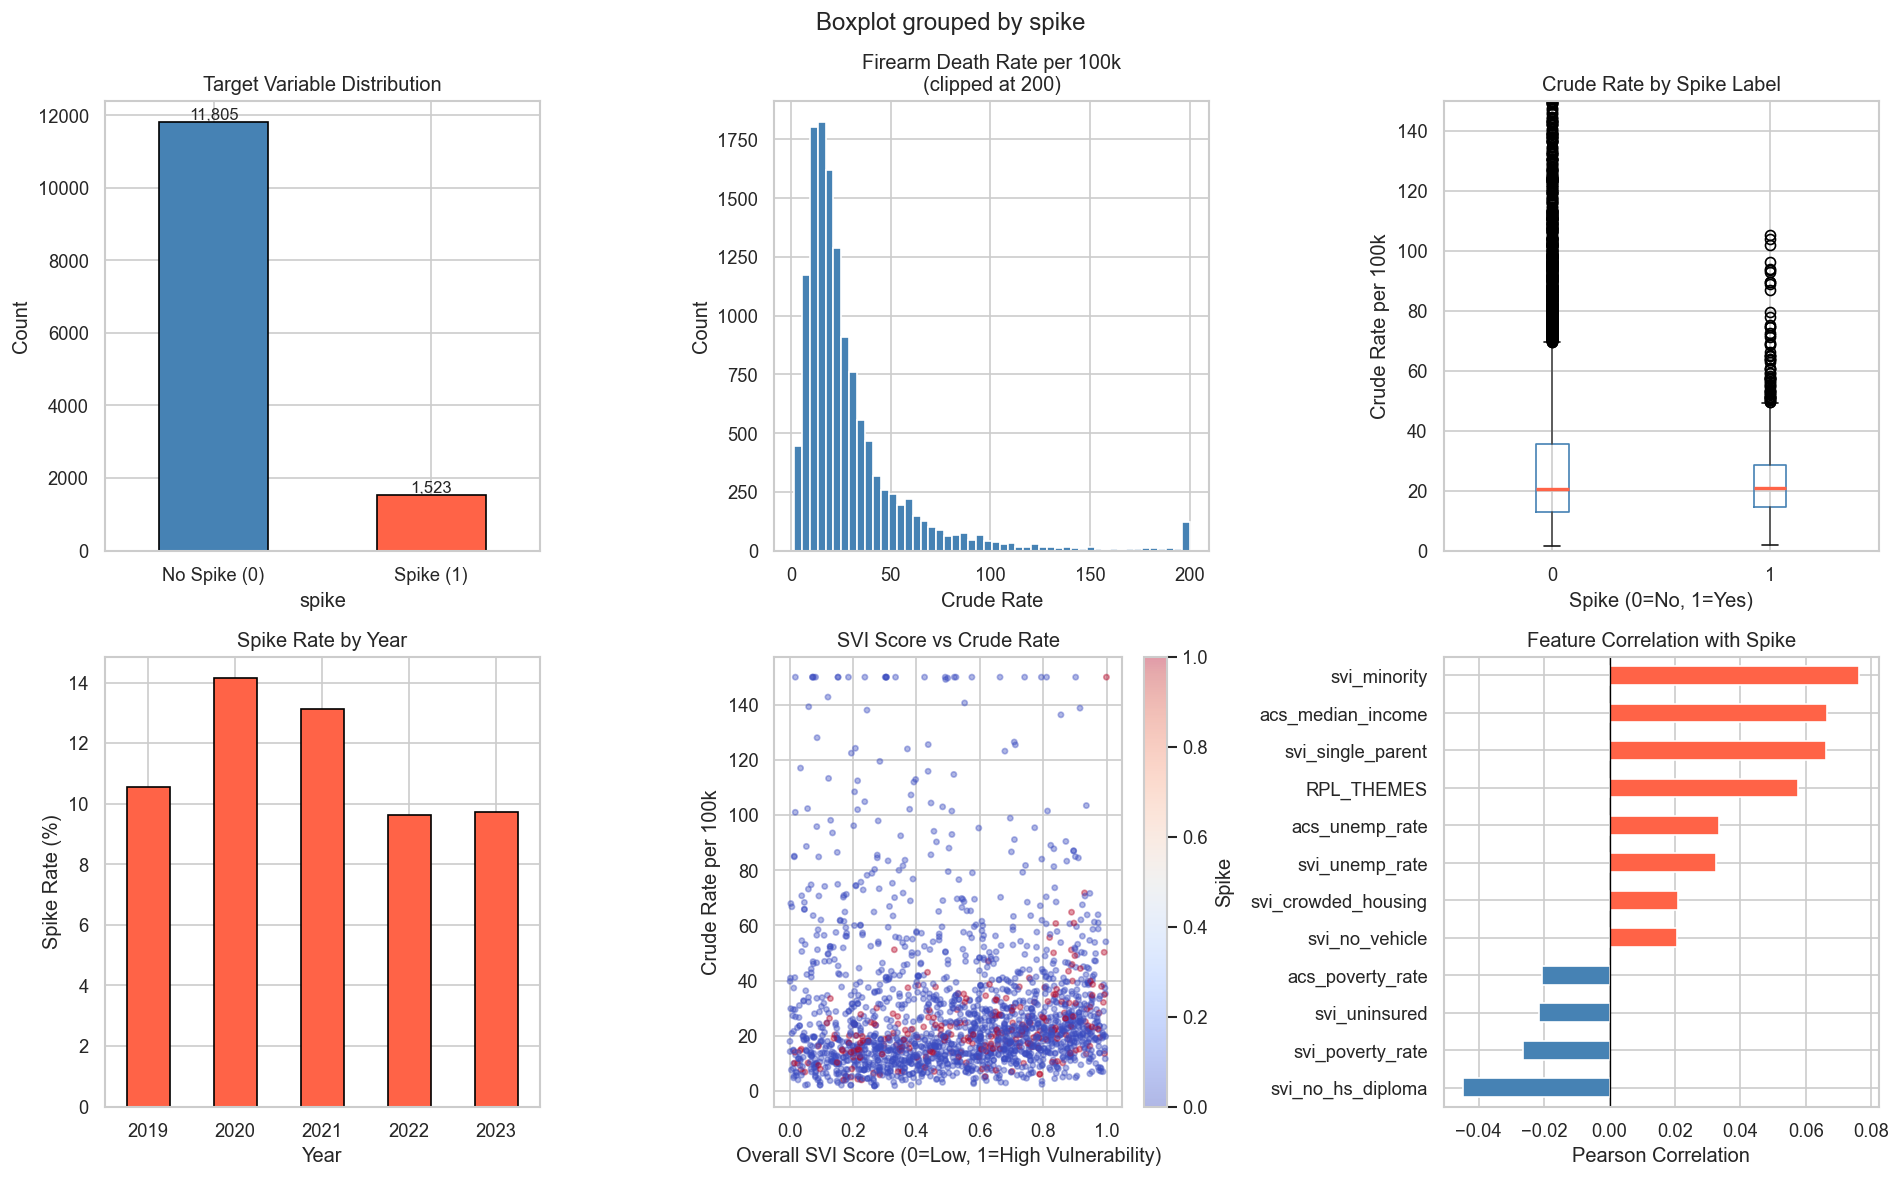

Saved: eda_overview.png


In [16]:
# =========================
# CELL 11: EDA — VISUALIZATIONS
# =========================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Gun Violence Early Warning System — EDA', fontsize=14, fontweight='bold')

# 1. Target distribution
ax = axes[0, 0]
df['spike'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='black')
ax.set_title('Target Variable Distribution')
ax.set_xticklabels(['No Spike (0)', 'Spike (1)'], rotation=0)
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

# 2. Crude rate distribution (log scale)
ax = axes[0, 1]
df['crude_rate'].clip(upper=200).hist(bins=50, ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Firearm Death Rate per 100k\n(clipped at 200)')
ax.set_xlabel('Crude Rate')
ax.set_ylabel('Count')

# 3. Crude rate by spike
ax = axes[0, 2]
df.boxplot(column='crude_rate', by='spike', ax=ax,
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='tomato', linewidth=2))
ax.set_title('Crude Rate by Spike Label')
ax.set_xlabel('Spike (0=No, 1=Yes)')
ax.set_ylabel('Crude Rate per 100k')
plt.sca(ax)
plt.title('Crude Rate by Spike Label')
ax.set_ylim(0, 150)

# 4. Spike rate by year
ax = axes[1, 0]
spike_by_year = df.groupby('year')['spike'].mean() * 100
spike_by_year.plot(kind='bar', ax=ax, color='tomato', edgecolor='black')
ax.set_title('Spike Rate by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Spike Rate (%)')
ax.set_xticklabels(spike_by_year.index, rotation=0)

# 5. SVI score vs crude rate
ax = axes[1, 1]
sample = df.sample(2000, random_state=42)
scatter = ax.scatter(sample['RPL_THEMES'], sample['crude_rate'].clip(upper=150),
                     c=sample['spike'], cmap='coolwarm', alpha=0.4, s=10)
ax.set_title('SVI Score vs Crude Rate')
ax.set_xlabel('Overall SVI Score (0=Low, 1=High Vulnerability)')
ax.set_ylabel('Crude Rate per 100k')
plt.colorbar(scatter, ax=ax, label='Spike')

# 6. Top feature correlations with spike
ax = axes[1, 2]
corr_cols = [
    'svi_unemp_rate', 'svi_poverty_rate', 'svi_no_hs_diploma',
    'svi_uninsured', 'svi_minority', 'svi_single_parent',
    'svi_no_vehicle', 'svi_crowded_housing', 'RPL_THEMES',
    'acs_median_income', 'acs_poverty_rate', 'acs_unemp_rate'
]
corrs = df[corr_cols + ['spike']].corr()['spike'].drop('spike').sort_values()
corrs.plot(kind='barh', ax=ax, color=['tomato' if x > 0 else 'steelblue' for x in corrs])
ax.set_title('Feature Correlation with Spike')
ax.set_xlabel('Pearson Correlation')
ax.axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('eda_overview.png', bbox_inches='tight')
plt.show()
print('Saved: eda_overview.png')

In [17]:
import os
files = [f for f in os.listdir('.') if f.endswith('.csv')]
print(files)

['gun_violence_final.csv', 'gun_violence_master.csv', 'SVI_2018_US_county.csv', 'SVI_2020_US_county.csv', 'Underlying Cause of Death, 2018-2024, Single Race (2).csv']
